In [148]:
# 绘制中国省份的代码
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns
from matplotlib.patches import Patch
from cnmaps import get_adm_maps, draw_maps, clip_pcolormesh_by_map

PROVINCE_FULL_NAME_TO_SHORT_NAME_MAP =  {
    '北京市': '北京',
    '天津市': '天津',
    '河北省': '河北',
    '山西省': '山西',
    '内蒙古自治区': '内蒙古',
    '辽宁省': '辽宁',
    '吉林省': '吉林',
    '黑龙江省': '黑龙江',
    '上海市': '上海',
    '江苏省': '江苏',
    '浙江省': '浙江',
    '安徽省': '安徽',
    '福建省': '福建',
    '江西省': '江西',
    '山东省': '山东',
    '河南省': '河南',
    '湖北省': '湖北',
    '湖南省': '湖南',
    '广东省': '广东',
    '广西壮族自治区': '广西',
    '海南省': '海南',
    '重庆市': '重庆',
    '四川省': '四川',
    '贵州省': '贵州',
    '云南省': '云南',
    '西藏自治区': '西藏',
    '陕西省': '陕西',
    '甘肃省': '甘肃',
    '青海省': '青海',
    '宁夏回族自治区': '宁夏',
    '新疆维吾尔自治区': '新疆',
    '台湾省': '台湾',
    '香港特别行政区': '香港',
}

PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP = {v:k for k,v in PROVINCE_FULL_NAME_TO_SHORT_NAME_MAP.items()}
PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP
def plot_china_provinces(

    data,
    province: str,
    group: str,
    china_provinces=None,   # ✅ 改这里
    group_order=None,
    palette=None,
    color=None,
    lw = 0.8,
    line_color = "black",
    legend: bool = True,
    legend_title: str | None = None,
    geom_kws: dict | None = None,
    geom_kws_by_name: dict | None = None,
    legend_kws: dict | None = None,
    legend_handles_kws: dict | None = None,
    ax=None,
    figsize = (6,4),
    dpi = 300
):
    """
    Province 应该是全称，如北京市，台湾省等
    """
    if ax is None:
        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax = plt.axes(projection=ccrs.PlateCarree())
    # ==== 0. map init（关键新增）====
    if china_provinces is None:
        china_provinces = get_adm_maps(
            country="中华人民共和国",
            level="省",
            only_polygon=False
        )

    geom_kws = {} if geom_kws is None else dict(geom_kws)
    geom_kws_by_name = {} if geom_kws_by_name is None else dict(geom_kws_by_name)
    legend_kws = {} if legend_kws is None else dict(legend_kws)
    legend_handles_kws = {} if legend_handles_kws is None else dict(legend_handles_kws)


    # ==== 1. group order ====
    groups = list(group_order) if group_order is not None else list(data[group].unique())

    # ==== 2. color mapping（完全对齐你的 barplot 逻辑）====
    if palette is not None:
        if isinstance(palette, dict):
            color_map = palette
        else:
            colors = (
                palette
                if isinstance(palette, (list, tuple))
                else sns.color_palette(palette, len(groups))
            )
            color_map = {g: colors[i % len(colors)] for i, g in enumerate(groups)}
    else:
        base_color = color if color is not None else sns.color_palette("Set2", 1)[0]
        color_map = {g: base_color for g in groups}

    # ==== 3. province -> group ====
    province_to_group = dict(zip(data[province], data[group]))

    # ==== 4. axis ====
    ax.set_extent([73, 136, 18, 54], crs=ccrs.PlateCarree())

    # ==== 5. draw ====
    for prov in china_provinces:
        name = prov["province"]
        poly = prov.geometry.geom

        g = province_to_group.get(name, None)

        # --- default geom
        default_geom = {
            "facecolor": color_map.get(g, "lightgrey"),
            "edgecolor": "black",
            "linewidth": 0.5,
            "alpha": 0.9,
            "zorder": 1,
        }

        # --- merge（和你 barplot 完全一致）
        merged_geom = {
            **default_geom,
            **geom_kws,
            **geom_kws_by_name.get(name, {}),
        }

        ax.add_geometries(
            [poly],
            crs=ccrs.PlateCarree(),
            **merged_geom,
        )

    # ==== 6. boundary ====
    draw_maps(china_provinces, linewidth=lw, color=line_color, ax=ax)

    # ==== 7. legend ====
    if legend:

        # --- default handle（控制 Patch 样式）
        default_handle = {
            "edgecolor": "black",
            "linewidth": 0.8,
        }

        merged_handle = {
            **default_handle,
            **legend_handles_kws,
        }

        handles = [
            Patch(
                facecolor=color_map[g],
                label=str(g),
                **merged_handle
            )
            for g in groups
        ]

        # --- default legend（整体 legend 样式）
        default_legend = {
            "title": legend_title or group,
            "fontsize": 7,
            "title_fontsize": 8,
            "frameon": False,
        }

        merged_legend = {
            **default_legend,
            **legend_kws,
        }

        ax.legend(
            handles=handles,
            **merged_legend,
        )



    return ax


In [149]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

from tqdm import tqdm
import torch


def predict_forecasts(
    model,
    data,
    target,
    # horizon=None,
    # lookback=None,
    device="cpu",
    target_normalizer=None,
    batch_size=64,
):
    """
    Rolling multi-step forecasting.

    Strictly preserves the original windowing logic:
        for i in range(0, len(data) - horizon - lookback, horizon):
            history = data[i:i + lookback]
            label = target[i + lookback:i + lookback + horizon]

    Returns
    -------
    predictions : torch.Tensor
        Flattened predictions.
    groundtruth : torch.Tensor
        Flattened ground truth.
    label_indices : list[int]
        Flattened time indices aligned with predictions / groundtruth.
    """
    horizon = model.horizon if hasattr(model, 'horizon') else None 
    lookback =  model.lookback if hasattr(model, 'lookback') else None 

    if horizon is None or lookback is None:
        raise ValueError("`horizon` and `lookback` must be provided.")
    if batch_size <= 0:
        raise ValueError("`batch_size` must be a positive integer.")

    data = torch.as_tensor(data, dtype=torch.float32)
    target = torch.as_tensor(target, dtype=torch.float32)

    histories, labels, start_indices = _build_forecast_windows(
        data=data,
        target=target,
        lookback=lookback,
        horizon=horizon,
    )

    prediction_chunks = []
    groundtruth_chunks = []
    label_indices = []
    if hasattr(model, "to"):
        model.to(device)
    # else:

    with torch.no_grad():
        for start in tqdm(range(0, histories.shape[0], batch_size)):
            end = min(start + batch_size, histories.shape[0])

            batch_history = histories[start:end]
            batch_label = labels[start:end]

            preds = _run_model_predict(
                model=model,
                batch_history=batch_history,
                device=device,
            )
            preds = preds.detach().cpu()
            preds = _maybe_inverse_transform(preds, target_normalizer)

            preds = _normalize_prediction_shape(preds)
            batch_label = _normalize_prediction_shape(batch_label)

            if preds.shape != batch_label.shape:
                raise ValueError(
                    f"Prediction shape {tuple(preds.shape)} does not match "
                    f"label shape {tuple(batch_label.shape)}."
                )

            for b in range(preds.shape[0]):
                pred_item = preds[b].reshape(-1)
                label_item = batch_label[b].reshape(-1)

                if pred_item.numel() != label_item.numel():
                    raise ValueError(
                        f"Prediction length ({pred_item.numel()}) does not match "
                        f"label length ({label_item.numel()})."
                    )

                prediction_chunks.append(pred_item)
                groundtruth_chunks.append(label_item)

                i = start_indices[start + b]
                label_indices.extend(range(i + lookback, i + lookback + horizon))

    predictions = torch.cat(prediction_chunks, dim=0)
    groundtruth = torch.cat(groundtruth_chunks, dim=0)

    return predictions, groundtruth, label_indices


def _build_forecast_windows(data, target, lookback, horizon):
    """
    按原始逻辑构造 rolling forecasting windows.
    """
    history_chunks = []
    label_chunks = []
    start_indices = []

    for i in range(0, len(data) - horizon - lookback, horizon):
        history = data[i:i + lookback]
        label = target[i + lookback:i + lookback + horizon]

        history_chunks.append(history)
        label_chunks.append(label)
        start_indices.append(i)

    if not history_chunks:
        raise ValueError("No valid forecasting windows were generated.")

    histories = torch.stack(history_chunks, dim=0)
    labels = torch.stack(label_chunks, dim=0)

    return histories, labels, start_indices


def _run_model_predict(model, batch_history, device="cpu"):
    """
    兼容 torch model 和 sklearn-like model 的预测接口.
    """
    batch_history = batch_history.to(device)
    if not hasattr(model, "to") and hasattr(model, "predict"):
        # sklearn / xgboost / tabpfn 风格
        output = model.predict(batch_history)
    else:
        # torch / lightning 风格
        batch_history = batch_history.to(device)
        output = model(batch_history)

    return torch.as_tensor(output, dtype=torch.float32)


def _maybe_inverse_transform(preds, target_normalizer=None):
    """
    对预测结果做反归一化，并尽量兼容 torch / numpy 输出.
    """
    if target_normalizer is None:
        return torch.as_tensor(preds, dtype=torch.float32)

    preds_inv = target_normalizer.inverse_transform(preds)
    return torch.as_tensor(preds_inv, dtype=torch.float32)


def _normalize_prediction_shape(x):
    """
    将张量统一为:
    - (B, H)     for single-target
    - (B, H, D)  for multi-target

    当前逻辑：
    - 若为 (B, H, 1)，压成 (B, H)
    - 其他情况保持不变
    """
    x = torch.as_tensor(x, dtype=torch.float32)

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x.squeeze(-1)

    return x

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

def batch_forecast_eval(
    model, 
    data_bundle, 
    dataset_names=["test"], 
    num_cities=3, 
    batch_size=256, 
    device="cpu",
    plot=True,

):
    """
    批量进行城市预测、评估，并将所有图组合在一个 subplots 中。
    """
    # ====== 环境准备 ======

    city_order = data_bundle.all_city_names
    y_normalizer = data_bundle.y_normalizer
    time_index_all = data_bundle.time_index
    x_transformed = data_bundle.x_normalizer.transform(data_bundle.raw_x)
    y_raw = data_bundle.raw_y

    # 确定需要预测的所有城市任务清单
    task_list = []
    for dataset_name in dataset_names:
        if isinstance(num_cities, int):
            target_cities = data_bundle.city_name_dict.get(dataset_name, [])[:num_cities]
        else:
            target_cities = data_bundle.city_name_dict.get(dataset_name, [])
        for city_name in target_cities:
            task_list.append((dataset_name, city_name))

    total_tasks = len(task_list)
    if total_tasks == 0:
        return pd.DataFrame()

    # ====== 初始化 Subplots 画布 ======
    if plot:

        fig, axes = plt.subplots(1, num_cities, figsize=(5 * num_cities, 3.5 ), dpi=300)
        axes = axes.flatten() if total_tasks > 1 else [axes]
    
    all_dfs = []

    # ====== 遍历任务执行预测 ======
    for i, (dataset_name, city_name) in enumerate(task_list):
        k = city_order.index(city_name)
        data_used_x = x_transformed[:, k]
        target_used_y = y_raw[:, k]

        # 调用预测函数
        predictions, groundtruth, label_indices = predict_forecasts(
            model=model, data=data_used_x, target=target_used_y,
           device=device,
            target_normalizer=y_normalizer, batch_size=batch_size,
        )

        preds_np = predictions.detach().cpu().numpy()
        labels_np = groundtruth.detach().cpu().numpy()
        mse = mean_squared_error(labels_np, preds_np)
        mae = mean_absolute_error(labels_np, preds_np)

        time_index = pd.to_datetime([time_index_all[idx] for idx in label_indices])
        df = pd.DataFrame({
            "Time": time_index, "Preds": preds_np, "Labels": labels_np,
            "City": city_name, "Dataset": dataset_name
        })
        all_dfs.append(df)

        # ====== 绘图填充 ======
        if plot:
            ax = axes[i]
            _plot_on_ax(df, ax, city_name, dataset_name, mse)

    # 关闭多余的子图刻度
    if plot:
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
        plt.tight_layout()
        plt.show()

    return pd.concat(all_dfs, ignore_index=True)

def _plot_on_ax(df, ax, city_name, dataset_name, mse):
    """将预测结果绘制在指定的子图坐标轴(ax)上"""
    plot_df = df.melt(
        id_vars=["Time"], value_vars=["Preds", "Labels"],
        var_name="Type", value_name="Value"
    )
    
    sns.lineplot(
        data=plot_df, x="Time", y="Value", hue="Type", style="Type",
        palette={"Preds": "grey", "Labels": "red"},
        style_order=["Preds", "Labels"], ax=ax
    )
    ax.set_title(f"{city_name} ({dataset_name})\nMSE: {mse:.4f}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel("")
    ax.set_ylabel("Value")



In [150]:
# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei']   # 黑体
# 解决负号显示异常
matplotlib.rcParams['axes.unicode_minus'] = False



In [4]:
from EpiAI.dataset.io import load_disease_tensor 
from EpiAI.dataset.inspector import DatasetInspector
raw_data = load_disease_tensor("data/Align_data_tensor_with_name.pt")
inspector = DatasetInspector(raw_data)

features =inspector.show_features()


Available features:
  [0] 乙脑
  [1] 疟疾
  [2] 登革热
  [3] u10_mean
  [4] u10_max
  [5] u10_min
  [6] sp_mean
  [7] sp_max
  [8] sp_min
  [9] ssrdc_mean
  [10] ssrdc_max
  [11] ssrdc_min
  [12] t2m_mean
  [13] t2m_max
  [14] t2m_min
  [15] swvl2_mean
  [16] swvl2_max
  [17] swvl2_min
  [18] d2m_mean
  [19] d2m_max
  [20] d2m_min
  [21] v10_mean
  [22] v10_max
  [23] v10_min
  [24] swvl1_mean
  [25] swvl1_max
  [26] swvl1_min
  [27] skt_mean
  [28] skt_max
  [29] skt_min
  [30] tp_mean
  [31] tp_max
  [32] tp_min
  [33] ssrd_mean
  [34] ssrd_max
  [35] ssrd_min
  [36] tcc_mean
  [37] tcc_max
  [38] tcc_min
  [39] ws10_mean
  [40] ws10_max
  [41] ws10_min
  [42] month_sin
  [43] month_cos
  [44] year_idx_norm
  [45] is_warm_season


In [5]:
inspector.coords['Year/Month']

[datetime.datetime(2004, 1, 1, 0, 0),
 datetime.datetime(2004, 2, 1, 0, 0),
 datetime.datetime(2004, 3, 1, 0, 0),
 datetime.datetime(2004, 4, 1, 0, 0),
 datetime.datetime(2004, 5, 1, 0, 0),
 datetime.datetime(2004, 6, 1, 0, 0),
 datetime.datetime(2004, 7, 1, 0, 0),
 datetime.datetime(2004, 8, 1, 0, 0),
 datetime.datetime(2004, 9, 1, 0, 0),
 datetime.datetime(2004, 10, 1, 0, 0),
 datetime.datetime(2004, 11, 1, 0, 0),
 datetime.datetime(2004, 12, 1, 0, 0),
 datetime.datetime(2005, 1, 1, 0, 0),
 datetime.datetime(2005, 2, 1, 0, 0),
 datetime.datetime(2005, 3, 1, 0, 0),
 datetime.datetime(2005, 4, 1, 0, 0),
 datetime.datetime(2005, 5, 1, 0, 0),
 datetime.datetime(2005, 6, 1, 0, 0),
 datetime.datetime(2005, 7, 1, 0, 0),
 datetime.datetime(2005, 8, 1, 0, 0),
 datetime.datetime(2005, 9, 1, 0, 0),
 datetime.datetime(2005, 10, 1, 0, 0),
 datetime.datetime(2005, 11, 1, 0, 0),
 datetime.datetime(2005, 12, 1, 0, 0),
 datetime.datetime(2006, 1, 1, 0, 0),
 datetime.datetime(2006, 2, 1, 0, 0),
 datet

In [6]:
provinces = inspector.coords['province']
provinces

['上海',
 '云南',
 '内蒙古',
 '北京',
 '吉林',
 '四川',
 '天津',
 '宁夏',
 '安徽',
 '山东',
 '山西',
 '广东',
 '广西',
 '新疆',
 '江苏',
 '江西',
 '河北',
 '河南',
 '浙江',
 '海南',
 '湖北',
 '湖南',
 '甘肃',
 '福建',
 '西藏',
 '贵州',
 '辽宁',
 '重庆',
 '陕西',
 '青海',
 '黑龙江']

<GeoAxes: >

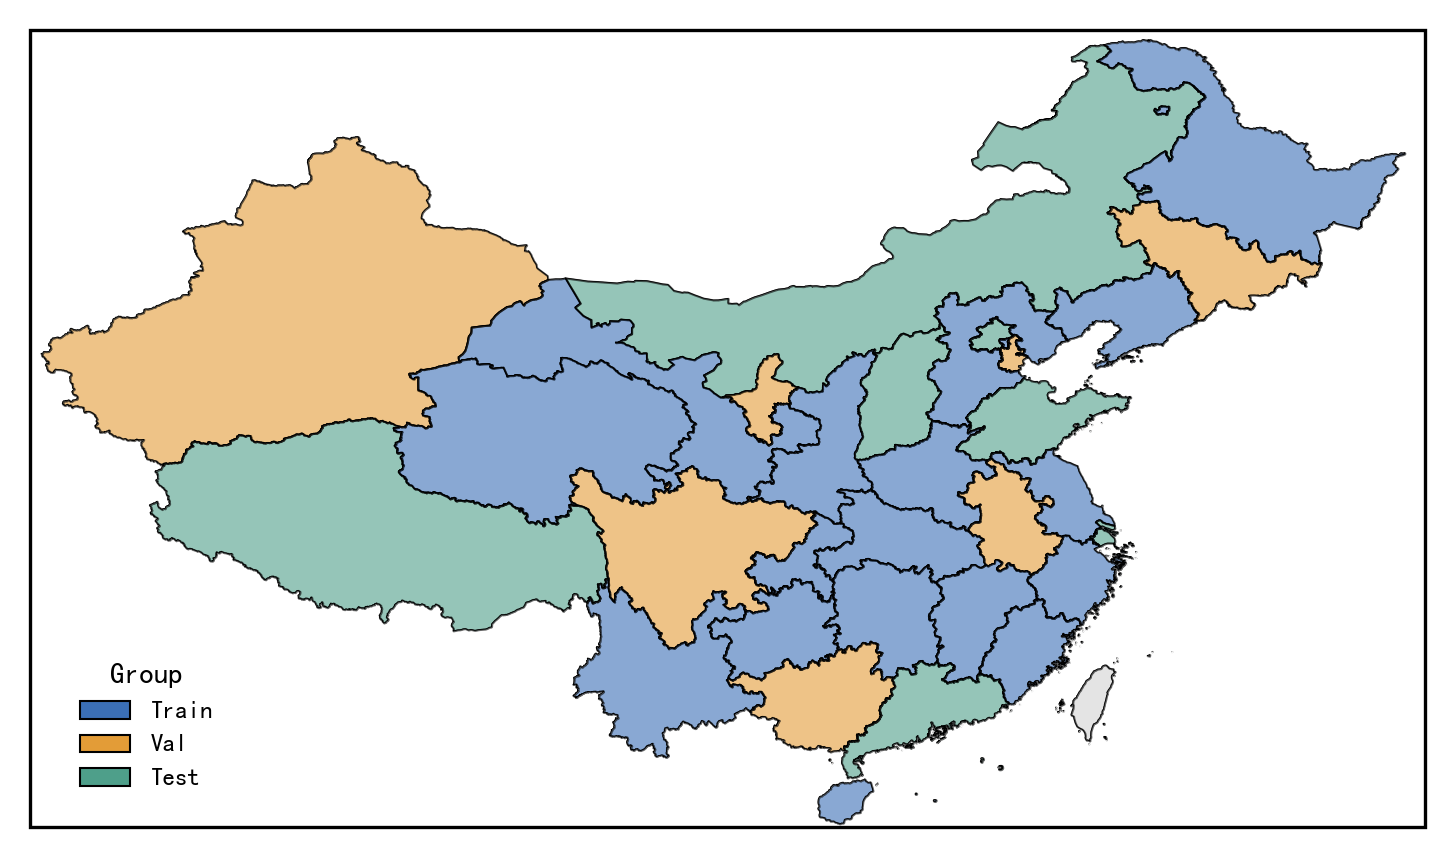

In [7]:
import pandas as pd

province_split_list = {
    'Train': [ '江西', '湖南', '贵州','云南', '浙江', '海南', '福建', '江苏', '河北', '河南', 
              '湖北', '甘肃',  '辽宁', '重庆', '陕西', '青海', '黑龙江'],
    'Val': ['吉林', '四川', '天津', '宁夏', '安徽', '新疆','广西',],
    'Test': ['上海', '内蒙古', '北京', '山东', '山西', '广东','西藏',]
}

train_indices = [provinces.index(i) for i in province_split_list['Train']]    # 云南、浙江、海南、福建
val_indices = [provinces.index(i) for i in province_split_list['Val']]    
test_indices = [provinces.index(i) for i in province_split_list['Test']]    

df = pd.DataFrame(list(province_split_list.items()), columns=['split', 'province'])

# 3. 使用 explode 方法将列表展开成多行
df = df.explode('province').reset_index(drop=True)
df['province'] = df['province'].replace(PROVINCE_SHORT_NAME_TO_FULL_NAME_MAP)
# 打印结果

plot_china_provinces(
    data=df,
    province="province",
    group="split",
    palette = {
        "Train": "#3B6FB6",
        "Val":   "#E39C37",
        "Test":  "#4E9F8A",
    },
    geom_kws={"alpha":0.6},
    lw= 0.2,
    legend_kws=dict(
        loc="lower left",
        bbox_to_anchor=(0.02, 0.02),
        fontsize=6,
        ncol=1,
        title_fontsize=7,
 
        frameon=False,
        title='Group'
    ),
    legend_handles_kws=dict(
    edgecolor="black",
    linewidth=.5
)
)


In [8]:
used_features = ['乙脑', '疟疾', '登革热', 'u10_mean', 'u10_max', 'u10_min', 'sp_mean', 'sp_max', 'sp_min', 'ssrdc_mean', 'ssrdc_max', 'ssrdc_min', 't2m_mean', 't2m_max', 't2m_min', 'swvl2_mean', 'swvl2_max', 'swvl2_min', 'd2m_mean', 'd2m_max', 'd2m_min', 'v10_mean', 'v10_max', 'v10_min', 'swvl1_mean', 'swvl1_max', 'swvl1_min', 'skt_mean', 'skt_max', 'skt_min', 'tp_mean', 'tp_max', 'tp_min', 'ssrd_mean', 'ssrd_max', 'ssrd_min', 'tcc_mean', 'tcc_max', 'tcc_min', 'ws10_mean', 'ws10_max', 'ws10_min']

In [9]:
from EpiAI.dataset import DatasetConfig, ForecastDataModule, MultiTargetCityDatasetBuilder
# 指定训练的省份
# train_indices = [1, 18, 19, 23, 13, 14, 16, 17, 20, 22, 24, 26, 27, 28, 29, 30]          # 云南、浙江、海南、福建
# val_indices = [ 12, 15, 21, 25, 4, 5, 6, 7, 8]       # 广东、广西、江西、湖南、贵州
# test_indices = [0, 2, 3 , 9, 10, 11,]

lookback = 12 
horizon = 3 
config = DatasetConfig(
    data_path="data/Align_data_tensor_with_name.pt",
    target_feature_names=["登革热"],
    input_feature_mode="explicit",
    input_feature_names=used_features,
    city_dim=1,
    split_mode="indices",  # cutoff
    train_city_indices = train_indices,
    val_city_indices = val_indices,
    test_city_indices = test_indices,
    lookback=lookback,
    horizon=horizon,
    ahead=0,
    normalize_x=True,
    normalize_y=True,
)

# builder = MultiTargetCityDatasetBuilder(config)
# bundle = builder.build()



In [10]:

datamodule = ForecastDataModule(
    dataset_config=config,
    batch_size=32,
    num_workers=4,
    train_shuffle=True
)

datamodule.setup("fit")
input_dim = datamodule.bundle.train_input.shape[-1]
target_dim = datamodule.bundle.train_target.shape[-1]
print(input_dim, target_dim)

42 1


In [11]:
# ## Test model 

# import torch
# import torch.nn as nn
# import lightning as L


# class ForecastLightningModule(L.LightningModule):
#     """
#     Generic LightningModule for multi-step, multi-target forecasting.

#     Model contract
#     --------------
#     The wrapped model must implement:
#         y_hat = model(x)

#     Input:
#         x.shape == (batch_size, lookback, input_dim)

#     Output:
#         y_hat.shape == (batch_size, horizon, target_dim)
#     """

#     def __init__(
#         self,
#         model: nn.Module,
#         lr: float = 1e-3,
#         weight_decay: float = 0.0,
#         loss_fn: nn.Module | None = None,
#     ) -> None:
#         super().__init__()
#         self.model = model
#         self.lr = lr
#         self.weight_decay = weight_decay
#         self.loss_fn = loss_fn if loss_fn is not None else nn.MSELoss()

#         self.save_hyperparameters(ignore=["model", "loss_fn"])

#     def forward(self, x: torch.Tensor) -> torch.Tensor:

#         return self.model(x)   

#     def _shared_step(self, batch, stage: str):
#         x, y = batch
#         y_hat = self(x)

#         if y_hat.shape != y.shape:
            
#             raise ValueError(
#                 f"{stage}: prediction shape {tuple(y_hat.shape)} does not match "
#                 f"target shape {tuple(y.shape)}."
#             )

#         loss = self.loss_fn(y_hat, y)

#         mae = torch.mean(torch.abs(y_hat - y))
#         rmse = torch.sqrt(torch.mean((y_hat - y) ** 2))
#         mse = torch.mean((y_hat - y) ** 2)

#         self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
#         self.log(f"{stage}_mae", mae, prog_bar=True, on_step=False, on_epoch=True)
#         self.log(f"{stage}_rmse", rmse, prog_bar=True, on_step=False, on_epoch=True)
#         self.log(f"{stage}_mse", mse, prog_bar=True, on_step=False, on_epoch=True)

#         return loss

#     def training_step(self, batch, batch_idx: int):
#         return self._shared_step(batch, stage="train")

#     def validation_step(self, batch, batch_idx: int):
#         self._shared_step(batch, stage="val")

#     def test_step(self, batch, batch_idx: int):
#         self._shared_step(batch, stage="test")

#     def configure_optimizers(self):
#         optimizer = torch.optim.Adam(
#             self.parameters(),
#             lr=self.lr,
#             weight_decay=self.weight_decay,
#         )
#         return optimizer



In [ ]:
import copy
import math
import os
from dataclasses import dataclass
from typing import Optional, Dict, Any

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm 

# =========================
# 1. Device
# =========================
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


# =========================
# 2. EarlyStopping
# =========================
class EarlyStopping:
    def __init__(
        self,
        monitor: str = "val_loss",
        mode: str = "min",
        patience: int = 10,
        min_delta: float = 0.0,
        restore_best_weights: bool = True,
    ):
        assert mode in ["min", "max"]
        self.monitor = monitor
        self.mode = mode
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best_score = None
        self.best_state_dict = None
        self.counter = 0
        self.should_stop = False

    def _is_improvement(self, current: float, best: float) -> bool:
        if self.mode == "min":
            return current < best - self.min_delta
        else:
            return current > best + self.min_delta

    def step(self, current_score: float, model: nn.Module):
        if self.best_score is None:
            self.best_score = current_score
            if self.restore_best_weights:
                self.best_state_dict = copy.deepcopy(model.state_dict())
            return

        if self._is_improvement(current_score, self.best_score):
            self.best_score = current_score
            self.counter = 0
            if self.restore_best_weights:
                self.best_state_dict = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore(self, model: nn.Module):
        if self.restore_best_weights and self.best_state_dict is not None:
            model.load_state_dict(self.best_state_dict)


# =========================
# 3. Train config
# =========================
@dataclass
class TrainConfig:
    max_epochs: int = 50
    lr: float = 1e-3
    weight_decay: float = 1e-3
    grad_clip_val: Optional[float] = 1.0
    patience: int = 10
    min_delta: float = 0.0
    monitor: str = "val_loss"
    monitor_mode: str = "min"
    use_scheduler: bool = False
    scheduler_patience: int = 5
    scheduler_factor: float = 0.5
    save_best_path: Optional[str] = "best_model.pt"
    print_every_epoch: bool = True


# =========================
# 4. One epoch: train
# =========================
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device,
    grad_clip_val: Optional[float] = None,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        # 这里假设 dataloader 返回 (x, y)
        # 如果你的是别的格式，我下面会告诉你怎么改
        x, y = batch
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()

        if grad_clip_val is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_val)

        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss


# =========================
# 5. One epoch: validate
# =========================
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    for batch in dataloader:
        x, y = batch
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    return avg_loss


# =========================
# 6. Main fit function
# =========================
def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    loss_fn: nn.Module,
    config: TrainConfig,
    optimizer: Optional[torch.optim.Optimizer] = None,
):
    device = get_device()
    model = model.to(device)

    if optimizer is None:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay,
        )

    scheduler = None
    if config.use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=config.monitor_mode,
            patience=config.scheduler_patience,
            factor=config.scheduler_factor,
        )

    early_stopper = EarlyStopping(
        monitor=config.monitor,
        mode=config.monitor_mode,
        patience=config.patience,
        min_delta=config.min_delta,
        restore_best_weights=True,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "best_val_loss": math.inf if config.monitor_mode == "min" else -math.inf,
    }

    print(f"Using device: {device}")

    for epoch in tqdm(range(1, (config.max_epochs + 1))):
        train_loss = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            grad_clip_val=config.grad_clip_val,
        )

        val_loss = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            loss_fn=loss_fn,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if config.print_every_epoch:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"Epoch [{epoch}/{config.max_epochs}] "
                f"train_loss={train_loss:.6f} "
                f"val_loss={val_loss:.6f} "
                f"lr={current_lr:.6e}"
            )

        # scheduler
        if scheduler is not None:
            scheduler.step(val_loss)

        # save best
        improved = False
        if config.monitor_mode == "min":
            if val_loss < history["best_val_loss"]:
                history["best_val_loss"] = val_loss
                improved = True
        else:
            if val_loss > history["best_val_loss"]:
                history["best_val_loss"] = val_loss
                improved = True

        if improved and config.save_best_path is not None:
            os.makedirs(os.path.dirname(config.save_best_path) or ".", exist_ok=True)
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": copy.deepcopy(model.state_dict()),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss,
                },
                config.save_best_path,
            )

        # early stopping
        early_stopper.step(val_loss, model)
        if early_stopper.should_stop:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # restore best weights in memory
    early_stopper.restore(model)

    print(f"Best val_loss: {early_stopper.best_score:.6f}")
    return model, history


# =========================
# 7. Example usage
# =========================
# 假设你已经有：
# model
# datamodule
# 并且 datamodule 有 train_dataloader() / val_dataloader()

# model = ...
# datamodule = ...

# loss_fn = nn.HuberLoss()

# config = TrainConfig(
#     max_epochs=50,
#     lr=1e-3,
#     weight_decay=1e-3,
#     grad_clip_val=1.0,
#     patience=10,
#     min_delta=0.0,
#     use_scheduler=False,
#     save_best_path="checkpoints/best_model.pt",
# )

# trained_model, history = fit_model(
#     model=model,
#     train_loader=datamodule.train_dataloader(),
#     val_loader=datamodule.val_dataloader(),
#     loss_fn=loss_fn,
#     config=config,
# )


## 测试深度学习的模型

In [13]:
import EpiAI.models.torch_models as EpiAI_torch_models
EpiAI_torch_models.__all__

['CNNLSTMForecaster',
 'CNNForecaster',
 'DLinearForecaster',
 'LSTMForecaster',
 'MLPForecaster',
 'ResNetForecaster',
 'TCNForecaster',
 'TransformerForecaster',
 'AutoformerForecaster',
 'TimesNetForecaster']

In [14]:
EpiAI_torch_models.__dict__['CNNForecaster']

EpiAI.models.torch_models.cnn.CNNForecaster

In [128]:
res_dict = {} 

cutoff = 1

cutoff_normed = datamodule.bundle.y_normalizer.transform(torch.Tensor([cutoff]).reshape(1,1,1)).numpy().flatten()[0]
cutoff_normed



np.float32(-0.08622442)

In [140]:
from pathlib import Path
from EpiAI.losses import *
default_train_config = dict(
        max_epochs=50,
        lr=5e-2,
        weight_decay=1e-3,
        grad_clip_val=1.0,
        patience=10,
        min_delta=0.0,
        use_scheduler=True,
        )


ProjectDir = Path('Dengues/torch_models')
for modelname in EpiAI_torch_models.__all__:
    save_best_path = ProjectDir/modelname
    save_best_path.mkdir(parents=True, exist_ok=True)

    if modelname in res_dict:
        print(f"{modelname} has been added")
        continue 

    # train use the default params
    model = EpiAI_torch_models.__dict__[modelname](
        lookback = lookback,
        horizon = horizon,
        input_dim = input_dim,
        target_dim = target_dim,
    )
    if (save_best_path/"best_model.pt").exists():
        model.load_state_dict(torch.load(save_best_path/"best_model.pt")['model_state_dict'])
    else:
        loss_fn = RegressionWithOutbreakBCELoss(outbreak_threshold=cutoff_normed)

        config = TrainConfig(

            save_best_path=save_best_path/"best_model.pt",
            **default_train_config

        )

        trained_model, history = fit_model(
            model=model,
            train_loader=datamodule.train_dataloader(),
            val_loader=datamodule.val_dataloader(),
            loss_fn=loss_fn,
            config=config,
        )
        
    results_df = batch_forecast_eval(
            model=model,
            data_bundle=datamodule.bundle,  # 确保参数名与函数定义一致

            num_cities="all",
            device='cpu',
            plot=False,
            dataset_names = ['train','val','test']
        )
    # format df 
    results_df = results_df.rename(columns = {"Preds":modelname})
    res_dict[modelname] = results_df
     
     


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.84it/s]


## 机器学习模型

In [141]:
import EpiAI.models.tabular_models as EpiAI_tabular_models

EpiAI_tabular_models.__all__

['LGBMSingleForecaster', 'XGBSingleForecaster', 'TabPFNMultiForecaster']

In [ ]:
from pathlib import Path
from EpiAI.losses import *
default_train_config = dict(
        max_epochs=50,
        lr=5e-2,
        weight_decay=1e-3,
        grad_clip_val=1.0,
        patience=10,
        min_delta=0.0,
        use_scheduler=True,
        )


ProjectDir = Path('Dengues/tabular_models')
for modelname in [ 'XGBSingleForecaster',]:
    save_best_path = ProjectDir/modelname
    save_best_path.mkdir(parents=True, exist_ok=True)

    if modelname in res_dict:
        print(f"{modelname} has been added")
        continue 

    # train use the default params
    model = EpiAI_tabular_models.__dict__[modelname](
        lookback = lookback,
        horizon = horizon,
        input_dim = input_dim,
        target_dim = target_dim,
        input_feature_names=datamodule.bundle.input_feature_names,

    )
    train_input = datamodule.bundle.train_input
    train_target = datamodule.bundle.train_target

    val_input = datamodule.bundle.val_input
    val_target = datamodule.bundle.val_target

    model.fit(
    x=train_input,
    y=train_target,
    # val_x = val_input,
    # val_y = val_target,
    # verbose = True
)
    results_df = batch_forecast_eval(
            model=model,
            data_bundle=datamodule.bundle,  # 确保参数名与函数定义一致

            num_cities="all",
            device='cpu',
            plot=False,
            dataset_names = ['train','val','test']
        )
    # format df 
    results_df = results_df.rename(columns = {"Preds":modelname})
    res_dict[modelname] = results_df
    break 
     


100%|██████████| 1/1 [00:00<00:00, 273.53it/s]


In [146]:
results_df = results_df.rename(columns = {"Preds":modelname})
res_dict[modelname] = results_df

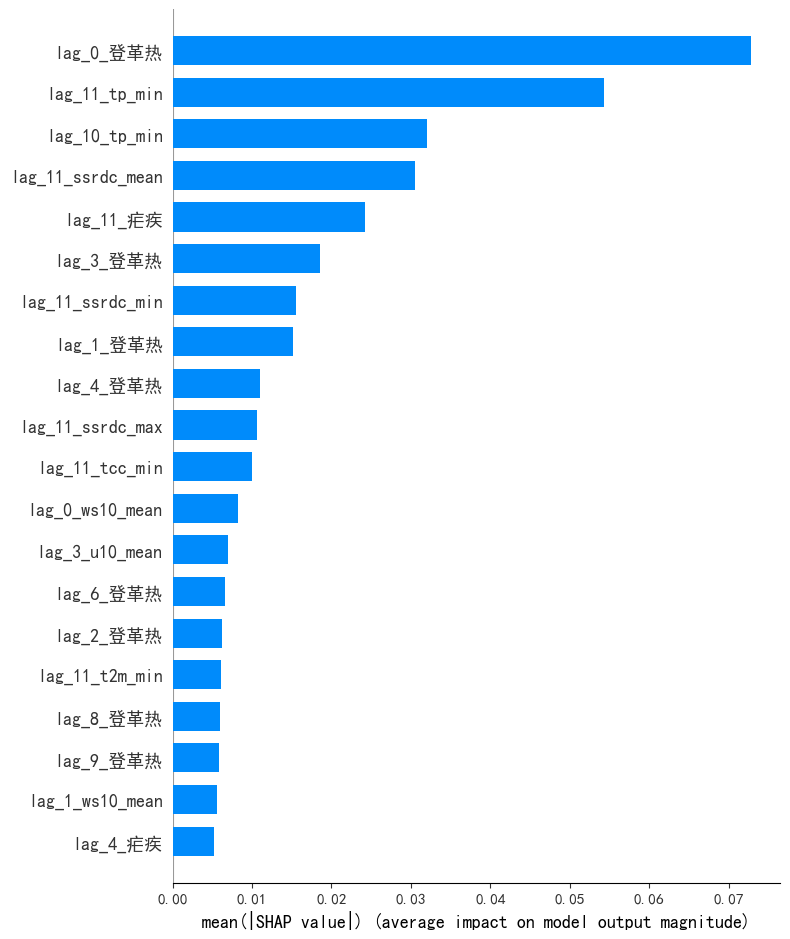

In [198]:
model.plot_shap_bar(
    x=train_input,
    horizon_idx=2,
    target_idx=0,
    max_display=20,
)


## 整合分析

In [144]:
res_dict['CNNLSTMForecaster']

,Time,CNNLSTMForecaster,Labels,City,Dataset
0,2005-01-01,-23.729261,0.0,江西,train
1,2005-02-01,-24.912880,0.0,江西,train
2,2005-03-01,-23.615232,0.0,江西,train
3,2005-04-01,-16.010069,0.0,江西,train
4,2005-05-01,-17.120281,0.0,江西,train
...,...,...,...,...,...
5854,2020-05-01,-15.152290,0.0,西藏,test
5855,2020-06-01,-12.501762,0.0,西藏,test
5856,2020-07-01,-14.224161,0.0,西藏,test
5857,2020-08-01,-8.608046,0.0,西藏,test


In [147]:
from functools import reduce 
df_all = reduce(lambda x,y: pd.merge(x,y ), res_dict.values())
df_all.to_feather("Dengue.feather")